# DeepFashion-MultiModal

U ovom notebook-u analiziramo tabelu sa outfitima koja je napravljena od DeepFashion-MultiModal
anotacija. Svaki red opisuje jednu fotografiju. Podaci dolaze iz tri fajla sa labelama, iz fajla
sa tekstualnim opisima i iz podatka o tome da li za sliku postoji segmentaciona maska.

Nijednu fotografiju ovde ne otvaramo jer sve što nam treba stoji u tekstu i u maskama. To je oko
110 MB podataka umesto arhive slika od 5.4 GB.

Zanimaju nas tri stvari. U labelama postoje dve vrste nedostajućih vrednosti koje izgledaju isto,
a ne znače isto. Vrednosti atributa su jako neravnomerno raspoređene, pa se neke pojavljuju na
desetinama hiljada slika, a neke na svega četiri. Isti odevni predmet je fotografisan više puta,
pa kod podele po slikama veći deo test skupa deli predmet sa trening skupom.

Nijedna od tih stvari se ne vidi iz broja redova, zato uz svaki grafikon ide i kratak zaključak
šta taj broj znači za treniranje modela.


## Učitavanje tabele

Licenca dataseta ne dozvoljava da tabelu držimo na gitu, pa je svako pravi lokalno kod sebe. Zbog
toga putanja do nje nije upisana u kodu nego se traži preko pomoćnih funkcija projekta. Ko drži
podatke negde drugde, samo postavi promenljivu `RMO_DATA_ROOT` i sve nastavlja da radi.

Ako tabela nije napravljena, učitavanje staje uz poruku koja objašnjava kako da se napravi. Tako
odmah znamo šta nedostaje, umesto da greška iskoči tek pri čitanju parquet fajla.


In [1]:
import hashlib
import itertools
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from rmo import paths
from rmo.data.parse_annotations import FABRIC_COLUMNS, PATTERN_COLUMNS, SHAPE_COLUMNS
from rmo.splits import SPLIT_NAMES, group_key_for, load_split

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

PRESENT, MISSING, ACCENT = "#4c72b0", "#c44e52", "#dd8452"
FIGURE_DIR = paths.ensure_dir(paths.repo_root() / "results" / "figures")


def save_figure(fig, name):
    """Upisuje nacrtani grafikon u direktorijum sa figurama."""
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


class MissingOutfitTable(RuntimeError):
    """Podiže se kada tabela sa outfitima nije napravljena u ovom checkout-u."""


def load_outfits():
    """Učitava tabelu sa outfitima ili objašnjava kako da se napravi."""
    table_path = paths.processed_dir() / "outfits.parquet"
    if not table_path.is_file():
        raise MissingOutfitTable(
            f"Nema tabele sa outfitima na putanji {table_path}.\n"
            "Licenca dataseta drži ovaj fajl van verzionisanja, pa se u svežem "
            "checkout-u prvo mora napraviti:\n"
            "    python scripts/download_data.py --labels-only --parsing --from <staging>\n"
            "    python scripts/build_dataset.py\n"
            "Podesi RMO_DATA_ROOT da bi se tabela čitala iz drugog direktorijuma."
        )
    return pd.read_parquet(table_path)


outfits = load_outfits()
outfits.shape


(44096, 26)

## Odakle dolazi svaka kolona

Tabela ima dvadeset šest kolona, ali svega četiri nezavisna izvora. To su tri fajla sa kodiranim
labelama, fajl sa tekstualnim opisima i podatak o tome da li maska postoji na disku.

Još četiri kolone ne dolaze ni iz jednog fajla nego iz samog imena slike. Sva imena su iste
strukture, četiri dela razdvojena crticama. Kod imena `MEN-Denim-id_00000089-02_7_additional`
prvi deo je `MEN`, drugi je kategorija `Denim`, treći je šifra proizvoda `id_00000089`, a
poslednji govori koji je ovo snimak tog proizvoda po redu.

Kolone `gender` i `category_from_filename` zato ne opisuju sadržaj slike. One su samo pročitane
iz imena fajla.


In [2]:
provenance = pd.Series(
    {
        "image_id": "ime fajla, ključ po kome se spajaju svi fajlovi sa anotacijama",
        "garment_id": "ime fajla, prefiks proizvoda zajednički za sve snimke jednog predmeta",
        "gender": "ime fajla",
        "category_from_filename": "ime fajla, kategorija odeće",
        **{column: "labels/fabric_ann.txt" for column in FABRIC_COLUMNS},
        **{column: "labels/pattern_ann.txt" for column in PATTERN_COLUMNS},
        **{column: "labels/shape_anno_all.txt" for column in SHAPE_COLUMNS},
        "caption": "captions.json",
        "has_shape": "izvedeno, shape fajl je imao red za ovu sliku",
        "has_parsing": "izvedeno, za ovu sliku postoji segmentaciona maska",
        "is_full_body": "izvedeno, isto što i has_parsing jer maske postoje samo za full-body snimke",
    },
    name="izvor",
)
assert set(provenance.index) == set(outfits.columns), "tabela sa izvorima više ne odgovara podacima"

summary = pd.DataFrame(
    {
        "izvor": provenance,
        "dtype": outfits.dtypes.astype(str),
        "različitih vrednosti": outfits.nunique(),
    }
).loc[outfits.columns]
summary.index.name = "kolona"
summary


,izvor,dtype,različitih vrednosti
kolona,,,
image_id,"ime fajla, ključ po kome se spajaju svi fajlov...",str,44096
garment_id,"ime fajla, prefiks proizvoda zajednički za sve...",str,8058
gender,ime fajla,str,2
category_from_filename,"ime fajla, kategorija odeće",str,17
upper_fabric,labels/fabric_ann.txt,category,8
lower_fabric,labels/fabric_ann.txt,category,8
outer_fabric,labels/fabric_ann.txt,category,8
upper_pattern,labels/pattern_ann.txt,category,8
lower_pattern,labels/pattern_ann.txt,category,8


## Dve različite vrste nedostajućih vrednosti

Shape atributi mogu da imaju vrednost `na` i lako je pomisliti da to znači da labela nedostaje.
Ne znači. U originalnoj dokumentaciji piše da `na` znači da se taj deo odeće ne vidi na slici.
Neko je dakle pogledao fotografiju i zapisao da je izrez zaklonjen, a to je podatak o slici a ne
rupa u podacima.

Postoji i drugi slučaj. Za 1,552 slike ne postoji red u shape fajlu. Te slike imaju fabric i
pattern labele, ali nemaju nijedan shape atribut. Kod to zapisuje u kolonu `has_shape` pre nego
što prazne shape kolone popuni sa `na`. Bez te kolone ne bismo mogli da razlikujemo sliku na
kojoj se izrez ne vidi od slike koja uopšte nije obeležena.


In [3]:
captioned = outfits["caption"].str.len().gt(0)
annotated = outfits["has_shape"]

coverage = pd.DataFrame(
    {
        "broj slika": [
            len(outfits),
            int(annotated.sum()),
            int((~annotated).sum()),
            int(captioned.sum()),
            int((~annotated & ~captioned).sum()),
            int(outfits["is_full_body"].sum()),
        ]
    },
    index=[
        "imaju fabric i pattern labele",
        "imaju shape anotaciju",
        "nemaju shape anotaciju",
        "imaju opis",
        "nemaju ni shape ni opis",
        "imaju segmentacionu masku (full body)",
    ],
)
coverage["udeo u tabeli"] = (coverage["broj slika"] / len(outfits)).map("{:.1%}".format)
coverage


,broj slika,udeo u tabeli
imaju fabric i pattern labele,44096,100.0%
imaju shape anotaciju,42544,96.5%
nemaju shape anotaciju,1552,3.5%
imaju opis,42537,96.5%
nemaju ni shape ni opis,1552,3.5%
imaju segmentacionu masku (full body),12701,28.8%


In [4]:
na_within_annotated = (
    outfits.loc[annotated, list(SHAPE_COLUMNS)]
    .astype(str)
    .eq("na")
    .sum()
    .sort_values(ascending=False)
    .to_frame("označeno kao na iako je anotirano")
)
na_within_annotated["udeo anotiranih slika"] = (
    na_within_annotated["označeno kao na iako je anotirano"] / int(annotated.sum())
).map("{:.1%}".format)
na_within_annotated


,označeno kao na iako je anotirano,udeo anotiranih slika
socks,28869,67.9%
lower_length,16962,39.9%
neckline,15494,36.4%
cardigan,13705,32.2%
navel_covered,12271,28.8%
ring,5001,11.8%
neckwear,4892,11.5%
glasses,4334,10.2%
hat,2159,5.1%
wrist,1797,4.2%


**Zaključak.** Slika bez shape anotacije ima 1,552 i to su tačno one iste slike koje nemaju ni
tekstualni opis. Znači da rupa nije nastala slučajno nego sistematski, pa ti redovi mogu da
posluže samo za fabric i pattern.

I među 42,544 anotirane slike `na` je čest. Kod atributa `socks` se stanje ne vidi na 67.9%
slika, a kod `cardigan` na 32.2%. Ako bismo `na` tretirali kao nedostajuću vrednost i izbacili te
redove, ostali bismo bez dve trećine kolone `socks`. Ako ga tretiramo kao običnu klasu, redovi
ostaju i to odgovara onome što je anotator zapisao. Zato svaki shape atribut treba da ima svoju
klasu za slučaj kada se deo odeće ne vidi.


## Koliko je koja kolona upotrebljiva

Ovde gledamo koliko `na` vrednosti ima u svakoj od osamnaest kolona sa labelama. Kada se sve
nacrta odjednom, odmah se vidi da su fabric i pattern upotrebljivi za gornji i donji deo odeće, a
skoro prazni za spoljni sloj. Shape atributi su razbacani po celom opsegu.

Procenti su računati na svih 44,096 redova, pa shape kolone uključuju i onih 1,552 neanotiranih
slika kao `na`.


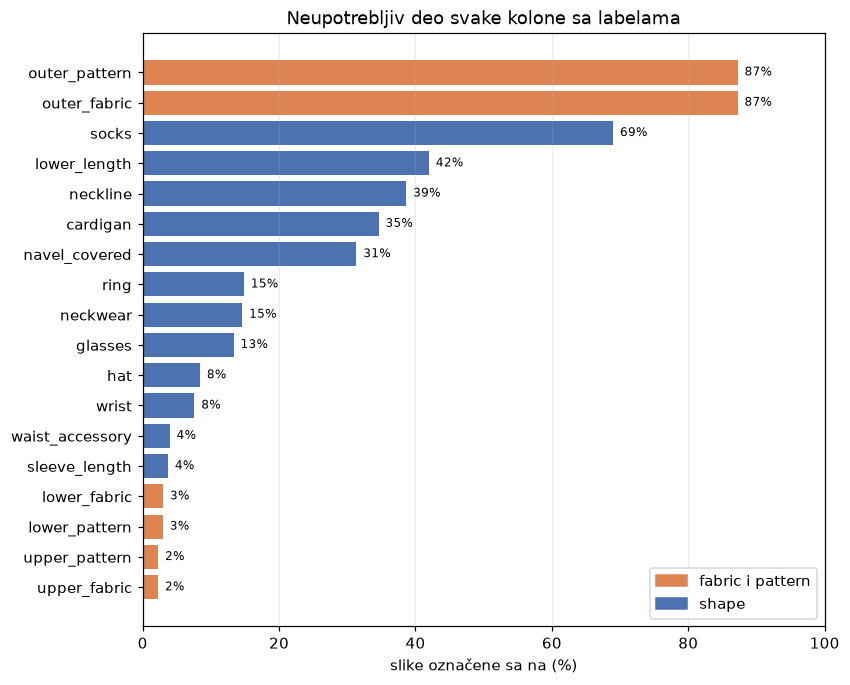

In [5]:
label_columns = [*FABRIC_COLUMNS, *PATTERN_COLUMNS, *SHAPE_COLUMNS]
na_rate = outfits[label_columns].astype(str).eq("na").mean().sort_values()
texture_columns = {*FABRIC_COLUMNS, *PATTERN_COLUMNS}

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    na_rate.index,
    na_rate.to_numpy() * 100,
    color=[ACCENT if name in texture_columns else PRESENT for name in na_rate.index],
)
for name, value in na_rate.items():
    ax.text(value * 100 + 1, name, f"{value:.0%}", va="center", fontsize=8)
ax.set_xlim(0, 100)
ax.set_xlabel("slike označene sa na (%)")
ax.set_title("Neupotrebljiv deo svake kolone sa labelama")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=ACCENT, label="fabric i pattern"),
        plt.Rectangle((0, 0), 1, 1, color=PRESENT, label="shape"),
    ],
    loc="lower right",
)
ax.grid(axis="y", visible=False)
save_figure(fig, "label_coverage")


**Zaključak.** Nijedna kolona nije popunjena do kraja i razlike su velike. Za `upper_fabric`
imamo svih 44,096 slika, a za bilo šta vezano za spoljni sloj odeće manje od 6,000. Ako bismo za
svaku kolonu pravili poseban izlaz modela, ti izlazi bi trenirali na potpuno različitim
količinama podataka. Zato pre nego što odlučimo šta model uči, treba pogledati koliko podataka
svaka kolona zaista ima.


## Spoljni sloj odeće je uglavnom neoznačen

Fabric i pattern se za svaku sliku beleže tri puta. Jednom za gornji deo odeće, jednom za donji i
jednom za spoljni sloj, odnosno jaknu ili kaput. Treći slot se ponaša sasvim drugačije od prva
dva.


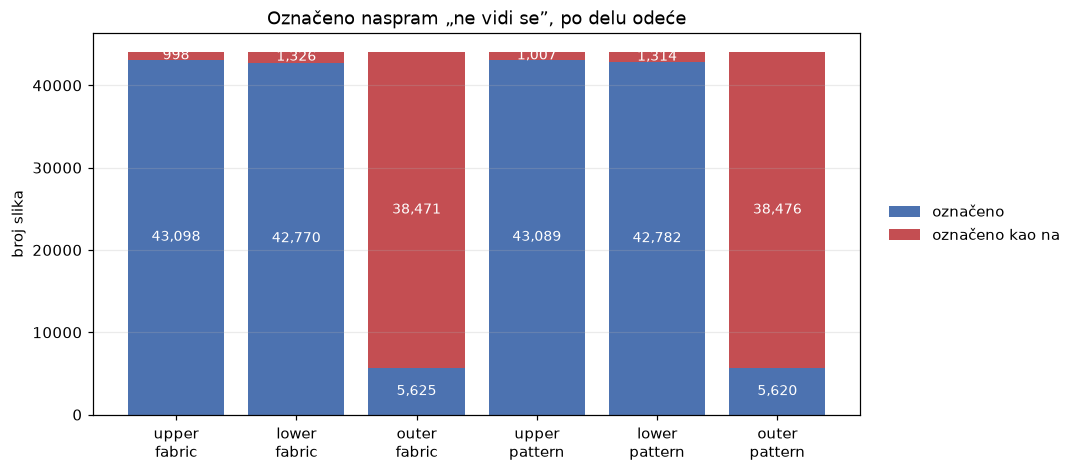

In [6]:
slots = [f"{part}_{kind}" for kind in ("fabric", "pattern") for part in ("upper", "lower", "outer")]
present = pd.Series({name: int(outfits[name].astype(str).ne("na").sum()) for name in slots})
absent = len(outfits) - present

positions = np.arange(len(slots))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(positions, present, color=PRESENT, label="označeno")
ax.bar(positions, absent, bottom=present, color=MISSING, label="označeno kao na")
for position, value in zip(positions, present):
    ax.text(position, value / 2, f"{value:,}", ha="center", va="center", color="white", fontsize=9)
for position, (base, value) in enumerate(zip(present, absent)):
    ax.text(position, base + value / 2, f"{value:,}", ha="center", va="center", color="white", fontsize=9)
ax.set_xticks(positions, [name.replace("_", "\n") for name in slots])
ax.set_ylabel("broj slika")
ax.set_title("Označeno naspram „ne vidi se”, po delu odeće")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.grid(axis="x", visible=False)
save_figure(fig, "outer_garment_coverage")


**Zaključak.** Spoljni sloj je označen sa `na` na 38,471 slici kod fabric i na 38,476 kod
pattern, što je oko 87% tabele. Razlog je jednostavan, većina ljudi na fotografijama nema jaknu na sebi. Ostaje oko 5,600 slika na kojima se taj slot uopšte može učiti.

Iz toga slede dve stvari. Poseban izlaz modela za spoljni sloj nema smisla praviti ravnopravno sa
izlazima za gornji i donji deo odeće. A ako ga ipak pravimo, „nema spoljnog sloja” mora da bude
klasa koju model predviđa, a ne vrednost koju maskiramo i preskačemo. U suprotnom model nikada ne
nauči najčešći slučaj.


## Izrez se često ne vidi

Atribut `neckline` opisuje izrez na gornjem delu odeće i najbolje pokazuje zašto je `na` stvarna
informacija a ne rupa u podacima. Izrez se vidi samo kada je gornji deo odeće u kadru i kada ga
ništa ne zaklanja.


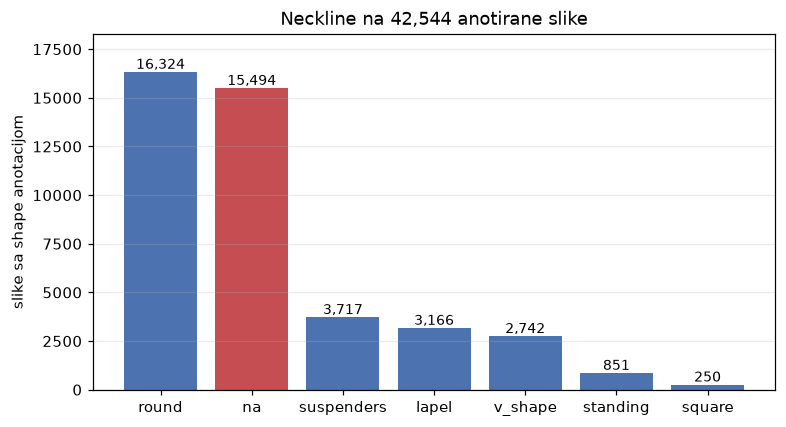

In [7]:
shaped = outfits.loc[annotated]
neckline = shaped["neckline"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.2))
colours = [MISSING if str(name) == "na" else PRESENT for name in neckline.index]
ax.bar([str(name) for name in neckline.index], neckline.to_numpy(), color=colours)
for position, value in enumerate(neckline.to_numpy()):
    ax.text(position, value, f"{value:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("slike sa shape anotacijom")
ax.set_title("Neckline na 42,544 anotirane slike")
ax.grid(axis="x", visible=False)
ax.margins(y=0.12)
save_figure(fig, "neckline_distribution")


**Zaključak.** Od 42,544 anotirane slike njih 15,494 ima izrez zaveden kao nevidljiv, što je
36.4%. Ostaje 27,050 slika sa stvarnom informacijom o izrezu, odnosno 63.6% anotiranog skupa.

I taj ostatak je neravnomeran. Vrednost `round` se javlja 16,324 puta, a `square` samo 250 puta,
što je odnos 65 prema 1. Ako `na` ostavimo kao sedmu klasu, model može da kaže da ne vidi izrez
umesto da pogađa. Rezultate treba gledati po klasama jer `round` i `na` zajedno čine 75% kolone i
sami bi podigli accuracy.


## Klase kojih skoro da nema

Prosečni procenti sakrivaju pravi problem. Kada prebrojimo svaku pojedinačnu vrednost atributa,
pojave se klase koje su praktično prazne.


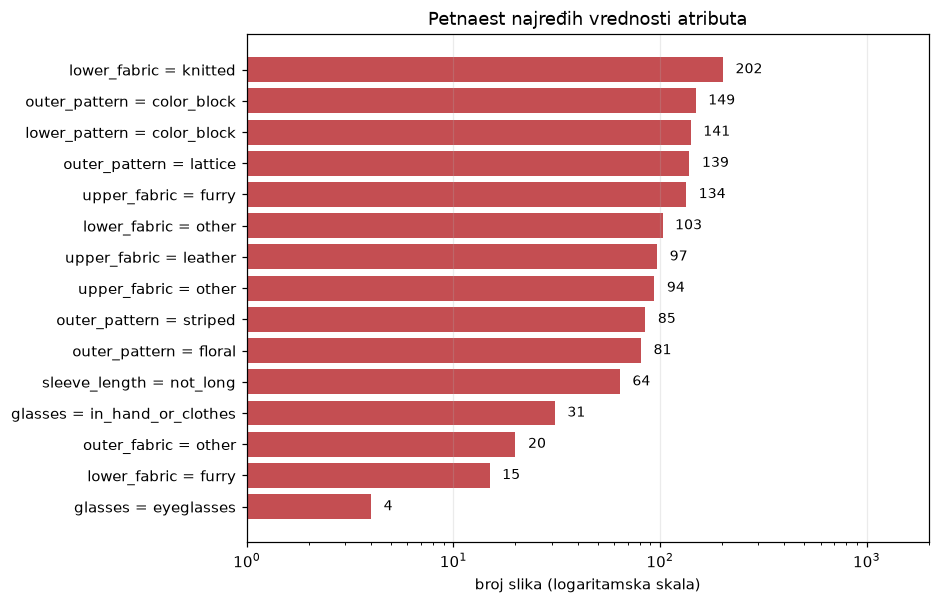

In [8]:
def class_counts(frame, columns):
    """Vraća po jedan red za svaki par (kolona, vrednost) sa brojem slika."""
    rows = []
    for column in columns:
        counts = frame[column].value_counts()
        for value, count in counts.items():
            rows.append({"column": column, "value": str(value), "images": int(count)})
    return pd.DataFrame(rows)


counts = pd.concat(
    [
        class_counts(outfits, [*FABRIC_COLUMNS, *PATTERN_COLUMNS]),
        class_counts(shaped, list(SHAPE_COLUMNS)),
    ],
    ignore_index=True,
)
rarest = (
    counts[counts["value"] != "na"]
    .nsmallest(15, "images")
    .assign(label=lambda frame: frame["column"] + " = " + frame["value"])
    .sort_values("images")
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(rarest["label"], rarest["images"], color=MISSING)
for label, value in zip(rarest["label"], rarest["images"]):
    ax.text(value * 1.15, label, f"{value:,}", va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlim(1, 2_000)
ax.set_xlabel("broj slika (logaritamska skala)")
ax.set_title("Petnaest najređih vrednosti atributa")
ax.grid(axis="y", visible=False)
save_figure(fig, "rare_classes")


**Zaključak.** Vrednost `eyeglasses` kod atributa `glasses` ima svega četiri slike, a
`in_hand_or_clothes` trideset jednu. Vrednost `not_long` kod `sleeve_length` ima šezdeset četiri
slike. Materijali `other`, `leather` i `furry` su svi ispod 140 slika.

Klasa sa četiri slike ne može da se podeli na trening, validacioni i test skup. Čak i
savršeno stratifikovana podela ostavlja najviše par primera sa svake strane, pa bilo kakav
rezultat za tu klasu predstavlja šum a ne merenje.

Ovde ne pomaže ni postupak koji se inače koristi kod neuravnoteženih podataka, a to je da retke
klase dobiju veću težinu. Ako svaka klasa dobije težinu obrnuto srazmernu broju slika, one četiri
slike sa `eyeglasses` zajedno vrede koliko i svih 37,547 slika bez naočara. Model bi onda učio
uglavnom iz ta četiri primera, koji su možda i pogrešno označeni.

Bolje je takve vrednosti spojiti sa najbližom sličnom klasom ili ih pre treniranja prebaciti u
`other`. Rezultat se onda računa kao prosek po klasama, gde svaka klasa ulazi podjednako bez
obzira koliko slika ima.


## Ko je na fotografijama

Neravnoteža ne postoji samo u labelama nego i u samom sastavu skupa. Ovde gledamo kako su slike
raspoređene po polu i po kategoriji odeće. To je bitno jer svaki zbirni rezultat najviše govori o
onome čega u podacima ima najviše.


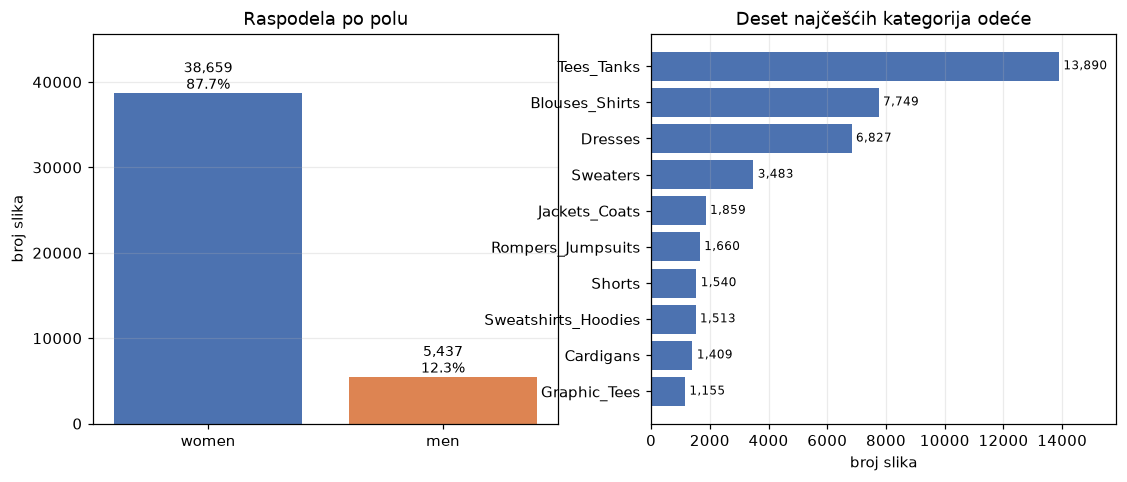

In [9]:
gender = outfits["gender"].value_counts()
categories = outfits["category_from_filename"].value_counts().head(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(gender.index.astype(str), gender.to_numpy(), color=[PRESENT, ACCENT])
for position, value in enumerate(gender.to_numpy()):
    axes[0].text(position, value, f"{value:,}\n{value / len(outfits):.1%}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("broj slika")
axes[0].set_title("Raspodela po polu")
axes[0].grid(axis="x", visible=False)
axes[0].margins(y=0.18)

axes[1].barh(categories.index.astype(str), categories.to_numpy(), color=PRESENT)
for label, value in zip(categories.index.astype(str), categories.to_numpy()):
    axes[1].text(value + 150, label, f"{value:,}", va="center", fontsize=8)
axes[1].set_xlabel("broj slika")
axes[1].set_title("Deset najčešćih kategorija odeće")
axes[1].grid(axis="y", visible=False)
axes[1].margins(x=0.14)
save_figure(fig, "subject_skew")


**Zaključak.** Na 38,659 slika su žene, a na 5,437 muškarci, što je odnos 88 prema 12. Kategorija
`Tees_Tanks` sama nosi 13,890 slika, skoro trećinu tabele. Jedan zbirni accuracy je zato pre
svega izjava o ženskim gornjim delovima odeće. Uz njega treba prikazati i rezultat posebno po
polu i po kategoriji, inače bi loš rezultat na muškoj odeći ostao sakriven iza nepromenjenog
proseka.


## Jedan predmet, više fotografija

U svakom imenu fajla stoji identifikator proizvoda. Prodavnice isti odevni predmet slikaju više
puta, u drugoj pozi, iz drugog kadra, ponekad i na drugoj osobi. Ako full-body slike grupišemo po
tom identifikatoru, vidi se koliko ponavljanja zapravo ima.


In [10]:
full_body = outfits.loc[outfits["is_full_body"], ["image_id"]].copy()
full_body["group"] = full_body["image_id"].map(group_key_for)
group_sizes = full_body["group"].value_counts()
size_histogram = group_sizes.value_counts().sort_index()

grouping = pd.DataFrame(
    {
        "vrednost": [
            f"{len(full_body):,}",
            f"{group_sizes.size:,}",
            f"{group_sizes.mean():.2f}",
            f"{int(group_sizes.max())}",
            f"{int((group_sizes > 1).sum()):,}",
            f"{int(group_sizes[group_sizes > 1].sum()):,} "
            f"({group_sizes[group_sizes > 1].sum() / len(full_body):.1%})",
        ]
    },
    index=[
        "full-body slika",
        "različitih grupa proizvoda",
        "prosečno slika po proizvodu",
        "najveća grupa proizvoda",
        "proizvoda slikanih više od jednom",
        "slika koje pripadaju višestruko slikanom proizvodu",
    ],
)
grouping


,vrednost
full-body slika,"12,701"
različitih grupa proizvoda,"6,932"
prosečno slika po proizvodu,1.83
najveća grupa proizvoda,35
proizvoda slikanih više od jednom,"2,694"
slika koje pripadaju višestruko slikanom proizvodu,"8,463 (66.6%)"


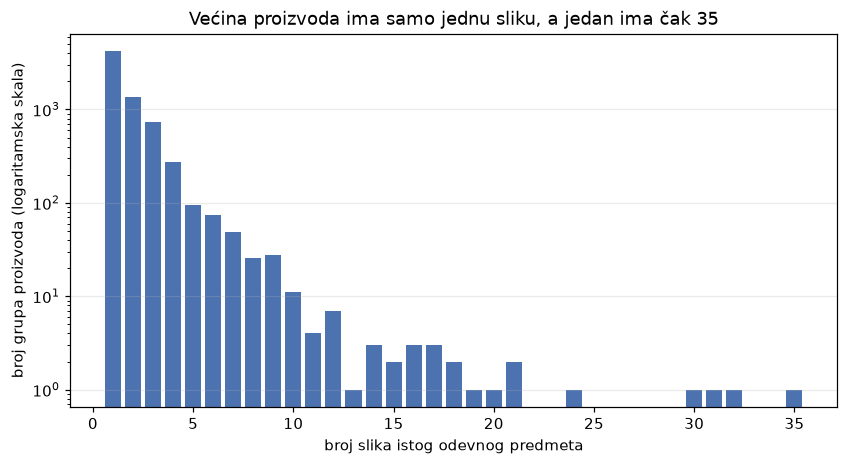

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(size_histogram.index, size_histogram.to_numpy(), color=PRESENT)
ax.set_yscale("log")
ax.set_xlabel("broj slika istog odevnog predmeta")
ax.set_ylabel("broj grupa proizvoda (logaritamska skala)")
ax.set_title("Većina proizvoda ima samo jednu sliku, a jedan ima čak 35")
ax.grid(axis="x", visible=False)
save_figure(fig, "garment_group_sizes")


## Zašto podela po slikama ne valja

Ako podatke delimo nasumično po slikama, fotografije istog proizvoda završe sa obe strane podele.
Model tada u testu vidi predmet koji je već učio, pa rezultat izgleda bolje nego što stvarno
jeste. To se zove data leakage.

Simulacija ispod nasumično izdvaja skup iste veličine kao postojeći test skup i broji koliko
izdvojenih slika ima drugu sliku istog proizvoda u ostatku podataka. Isto merenje se zatim
primenjuje i na podelu koju stvarno koristimo.


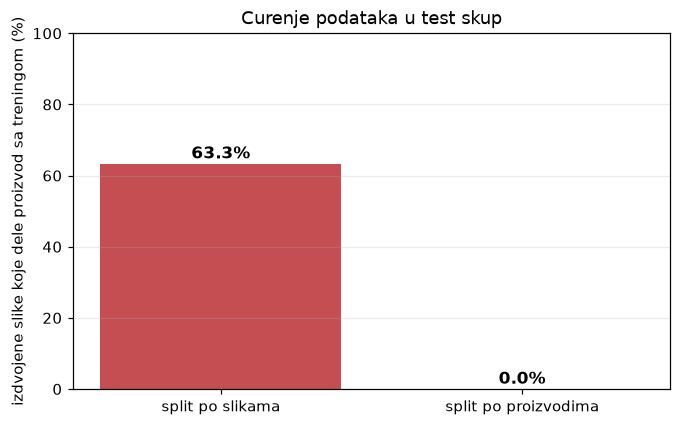

In [12]:
rng = np.random.default_rng(20260101)
test_size = len(load_split("test"))
groups_by_position = full_body["group"].to_numpy()

leak_rates = []
for _ in range(30):
    order = rng.permutation(len(full_body))
    held_out, remainder = groups_by_position[order[:test_size]], groups_by_position[order[test_size:]]
    leak_rates.append(np.isin(held_out, np.unique(remainder)).mean())
naive_leak = float(np.mean(leak_rates))

frozen = {name: load_split(name) for name in SPLIT_NAMES}
frozen_groups = {name: {group_key_for(image) for image in ids} for name, ids in frozen.items()}
frozen_leak = len(frozen_groups["test"] & (frozen_groups["train"] | frozen_groups["val"])) / len(
    frozen_groups["test"]
)

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(
    ["split po slikama", "split po proizvodima"],
    [naive_leak * 100, frozen_leak * 100],
    color=[MISSING, PRESENT],
)
for bar, value in zip(bars, [naive_leak, frozen_leak]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{value:.1%}",
        ha="center",
        fontsize=11,
        weight="bold",
    )
ax.set_ylim(0, 100)
ax.set_ylabel("izdvojene slike koje dele proizvod sa treningom (%)")
ax.set_title("Curenje podataka u test skup")
ax.grid(axis="x", visible=False)
save_figure(fig, "split_leakage")


In [13]:
digests = json.loads((paths.splits_dir() / "MANIFEST.json").read_text(encoding="utf-8"))
integrity = pd.DataFrame(
    {
        "broj slika": {name: len(ids) for name, ids in frozen.items()},
        "grupa proizvoda": {name: len(ids) for name, ids in frozen_groups.items()},
        "heš se poklapa sa manifestom": {
            name: hashlib.sha256((paths.splits_dir() / f"{name}.txt").read_bytes()).hexdigest()
            == digests["sha256"][f"{name}.txt"]
            for name in SPLIT_NAMES
        },
    }
)
shared = pd.Series(
    {
        f"{first} i {second}": len(frozen_groups[first] & frozen_groups[second])
        for first, second in itertools.combinations(SPLIT_NAMES, 2)
    },
    name="zajedničkih grupa proizvoda",
)
display(integrity, shared.to_frame())


,broj slika,grupa proizvoda,heš se poklapa sa manifestom
train,9071,4952,True
val,1815,990,True
test,1815,990,True


,zajedničkih grupa proizvoda
train i val,0
train i test,0
val i test,0


**Zaključak.** Od 12,701 full-body slike njih 8,463 pripada proizvodu koji je fotografisan više
puta, što je 66.6%. Najveća grupa ima 35 snimaka jednog istog proizvoda.

Zbog toga nasumična podela po slikama stavlja oko 63% test skupa u istu grupu sa nečim što je
model već video. Takav rezultat bi najvećim delom merio koliko je model zapamtio konkretne
proizvode, a ne koliko dobro radi na novim.

Podela po identifikatoru proizvoda to potpuno uklanja. Trening, validacioni i test skup nemaju
nijednu zajedničku grupu, pokrivaju 6,932 grupe kroz 9,071, 1,815 i 1,815 slika, a heš vrednosti
fajlova se i dalje poklapaju sa zapisanim manifestom. To znači da su ovo iste podele koje se
koriste i u kasnijim merenjima.


## U datasetu nema podataka o boji

U originalnoj dokumentaciji tri fajla sa labelama se opisuju kao „shape, fabric, and color
annotations”. Treći fajl nosi naslov *Color Annotations* i format
`<img_name> <upper_color> <lower_color> <outer_color>`. Osam vrednosti koje taj fajl sme da
sadrži govori nešto sasvim drugo.


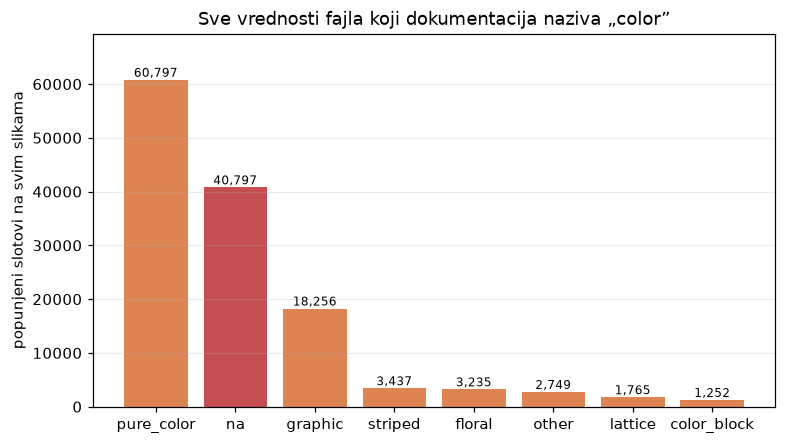

In [14]:
pattern_values = pd.concat([outfits[column] for column in PATTERN_COLUMNS]).value_counts()

fig, ax = plt.subplots(figsize=(8, 4.4))
labels = [str(name) for name in pattern_values.index]
ax.bar(labels, pattern_values.to_numpy(), color=[MISSING if name == "na" else ACCENT for name in labels])
for position, value in enumerate(pattern_values.to_numpy()):
    ax.text(position, value, f"{value:,}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("popunjeni slotovi na svim slikama")
ax.set_title('Sve vrednosti fajla koji dokumentacija naziva „color”')
ax.grid(axis="x", visible=False)
ax.margins(y=0.14)
save_figure(fig, "pattern_vocabulary")


In [15]:
COLOUR_WORDS = [
    "black", "white", "red", "blue", "green", "yellow", "pink",
    "grey", "gray", "brown", "purple", "orange", "beige", "navy",
]
captions = outfits.loc[captioned, "caption"].str.lower()
mentions_colour = captions.str.contains(rf"\b(?:{'|'.join(COLOUR_WORDS)})\b", regex=True)

colour_evidence = pd.DataFrame(
    {
        "vrednost": [
            f"{len(captions):,}",
            f"{int(mentions_colour.sum()):,}",
            "0 od 8",
        ]
    },
    index=[
        "opisa u tabeli",
        "opisa koji pominju neku od 14 čestih boja",
        'vrednosti „color” fajla koje imenuju boju',
    ],
)
display(colour_evidence, captions.head(3).to_frame("primer opisa"))


,vrednost
opisa u tabeli,"42,537"
opisa koji pominju neku od 14 čestih boja,0
vrednosti „color” fajla koje imenuju boju,0 od 8


,primer opisa
0,the lower clothing is of long length. the fabr...
1,"his tank top has sleeves cut off, cotton fabri..."
2,"his sweater has long sleeves, cotton fabric an..."


**Zaključak.** Osam dozvoljenih vrednosti su `floral`, `graphic`, `striped`, `pure_color`,
`lattice`, `other`, `color_block` i `na`. Sve su to šare, nijedna nije boja. Vrednost
`pure_color` znači da je predmet jednobojan ali ne kaže koje je boje, a `color_block` znači da se
na predmetu sudara više blokova ali ne kaže kojih. Fajl je zapravo anotacija šare sa pogrešnim
imenom. Vredi to naglasiti jer bi neko ko pročita samo dokumentaciju očekivao podatke o boji koji
ne postoje.

Ni tekstualni opisi tu ne pomažu. Nijedan od 42,537 opisa ne sadrži nijednu od četrnaest čestih
reči za boju. Razlog je što su opisi generisani po šablonu iz istog rečnika shape, fabric i
pattern vrednosti, na primer „The lower clothing is of long length. The fabric is cotton and it
has plaid patterns.”

Boje dakle nema nigde u datasetu, ni u labelama ni u tekstu. Sve što zahteva rad sa bojom mora da
je izračuna iz samih piksela. Delovi odeće se mogu razdvojiti samo tamo gde postoji segmentaciona
maska, pa je to moguće samo na 12,701 full-body slici.


## Šta se iz ove tabele može raditi

Fabric i pattern imamo za svih 44,096 slika, shape za 42,544, a segmentacionu masku za 12,701.
Koliko podataka nam ostaje zavisi od toga šta model treba da radi, a razlika između najvećeg i
najmanjeg skupa je skoro tri puta.

Nedostajuće vrednosti nisu slučajne. Spoljnog sloja odeće najčešće nema, izrez je često van
kadra, a 1,552 slike su ispale i iz shape fajla i iz fajla sa opisima. Zato „ne vidi se” treba da
bude klasa koju model predviđa a ne red koji izbacujemo.

Neke klase su toliko male da se na njima ništa ne može izmeriti i treba ih spojiti pre treniranja.
I pošto dve trećine full-body slika deli proizvod sa nekom drugom slikom, samo podela po
identifikatoru proizvoda daje rezultat koji nešto znači.
